# Example: how to begin

This notebook demonstrates some basic features through examples using the Cepheid system S Mus and Gaia Black Hole 3.

Here you can find:
- Basic simulation
- Usage of the provided plotting functions
- Fitting a single-star model
- Fitting with kepmodel
- Adding noise

In [51]:
from simbinary import SimBinary, fitGaia
import matplotlib.pyplot as plt

### A Cepheid S Mus

First, let’s initialize the system’s parameters. These parameters must be stored in a dictionary with the specific keys listed below.

In [52]:
params_SMus = {'Object': 'S Mus', #simbad resolved name
# 'id3': 12345..., if no gaia resolved name, write gaia dr3 id here
 'type': 'cepheid', # can be 'binary' or 'BH'
 'P': 506.3,
 'a': 2.95,
 'e': 0.088,
 'i': 144.7,
 'Omega': 99.6,
 'w': 194.8,
 'T0': 2457165.9,
 'q': 0.885,
 'plx': 1.167,
 'Vcomp': 8.2 # mandatory for types cepheid and binary
}
# The actual companion's magnitude is 9.12, but let's leave 8.2 to be able to see VIM zone

We can now proceed with the simulation. This step may take some time, as it will query Gaia and Simbad. You can avoid these queries by providing all the necessary information in advance, see BH3 below for an example.

When the simulation is produced for the first time for a given object, GOST data will be downloaded to the current folder. A notification stating “Downloading GOST data to your/folder” will appear. If you don't want to save GOST file, mark SaveGost = False.

If an unexpected error occurs during execution, check whether the Gaia archive or GOST services are under maintenance.

In [53]:
# Next line produces the simulation
sb_SMus = SimBinary(params_SMus, DataRelease = 4) # DataRelease from 1 to 5

sim_astrometry = sb_SMus.get_dataframe() # a dataframe with Gaia-like data
# If you want to save the dataframe, do sb.get_dataframe(data_dir='your/folder/')

Gaia DR3 ID added with Simbad
RA/DEC coordinates added with Gaia DR3
Proper motion RA/DEC added with Gaia DR3
Gmag added with Gaia DR3
Applying correction for DR3 proper motion...
Correction: -0.238±0.055 0.294±0.057
Proper motion corrected to: -7.901±0.162 and -1.805±0.163 mas


Note that a correction for proper motion is applied. Details of this correction will be provided in Section 2.3, Correction of proper motion bias for unresolved binaries (Sivkova, in prep.). If you want to avoid this correction, provide the parameters 'pmra' and 'pmdec'.

You can find the along scan positions in sim_astrometry['centroid_pos_al'] or sb.w_bs.

Text(0, 0.5, 'Along scan, [mas]')

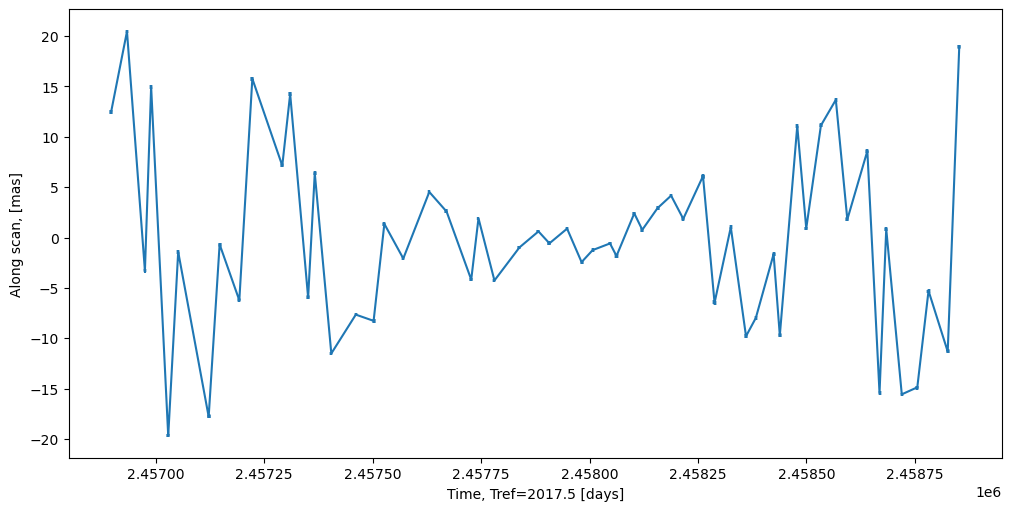

In [54]:
fig, ax = plt.subplots(1,1, figsize=(10, 5), constrained_layout=True)

ax.errorbar(sim_astrometry['obs_time_tcb'], sim_astrometry['centroid_pos_al'], yerr = sim_astrometry['centroid_pos_error_al'])
ax.set_xlabel(f'Time, Tref={sb.Tref} [days]')
ax.set_ylabel('Along scan, [mas]')


We can now proceed with the visualization. Available options include Plot, PlotCepheid, and PlotCepheidRow (horizontal layout).

Please note that the on-sky plot requires parallax factors to be generated. We approximate the parallactic motion as an ellipse to interpolate points between Gaia measurements (shown as a continuous line), which has its limitations. When zooming in, the scatter points may appear slightly shifted compared to the continuous line. This misapproximation occurs only in the visualization.

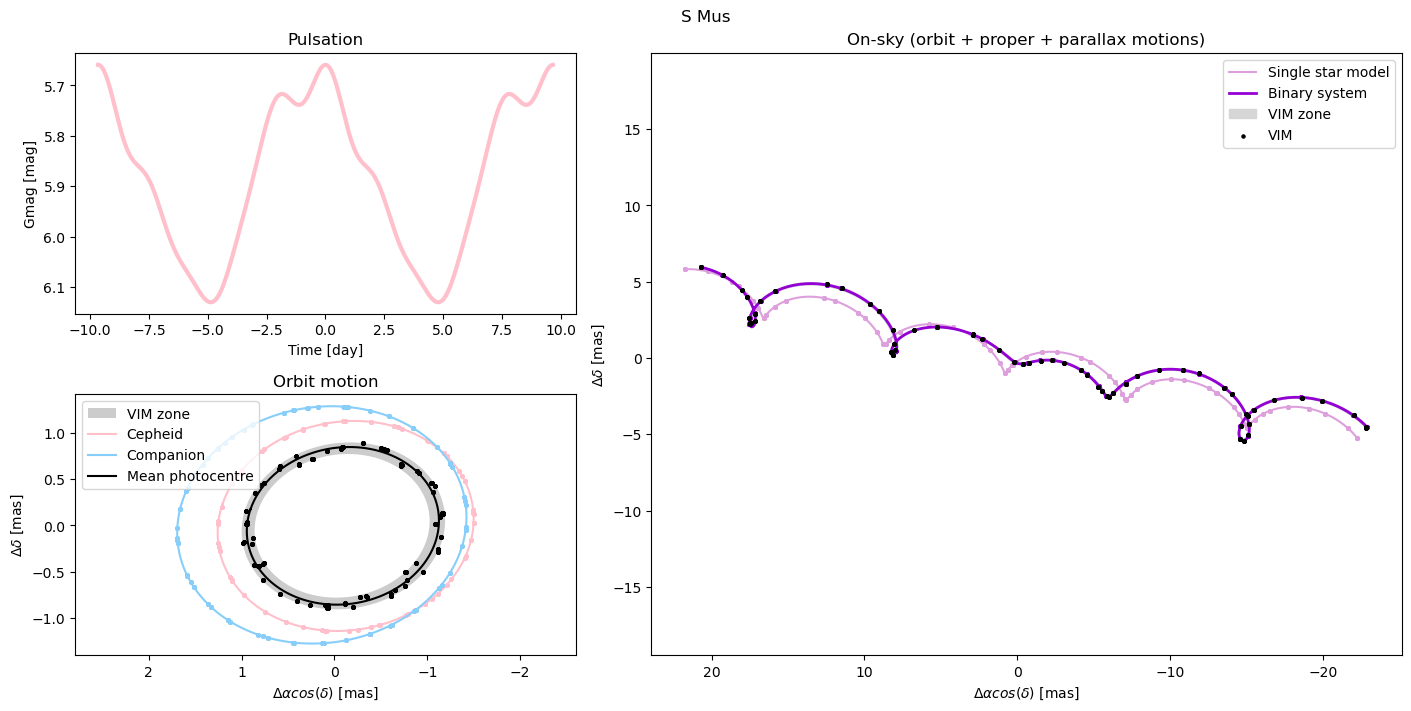

In [55]:
axs = sb_SMus.PlotCepheid(Npoints=500) # plot. for non pulsating targets use sb.Plot
# has plot_dir - a directory where it saves the plot and Npoints - number of points to consider for visualization


It is possible to quickly estimate the difference between the simulated data and the single-star model that would be fitted to it.

chi2r 13.985
a0 -0.1726 ± 0.1116
pmra -0.0215 ± 0.0002
d0 -0.055 ± 0.1138
pmdec -0.0048 ± 0.0002
plx 1.1398 ± 0.1334


array([[<Axes: title={'center': 'On sky (orbit + proper + parallax motions)'}, xlabel='$\\Delta \\alpha cos(\\delta)$ [mas]', ylabel='$\\Delta \\delta$ [mas]'>,
        <Axes: ylabel='AL positions [mas]'>],
       [<Axes: title={'center': 'Along scan positions'}, ylabel='Sky residuals [mas]'>,
        <Axes: ylabel='AL residuals [mas]'>]], dtype=object)

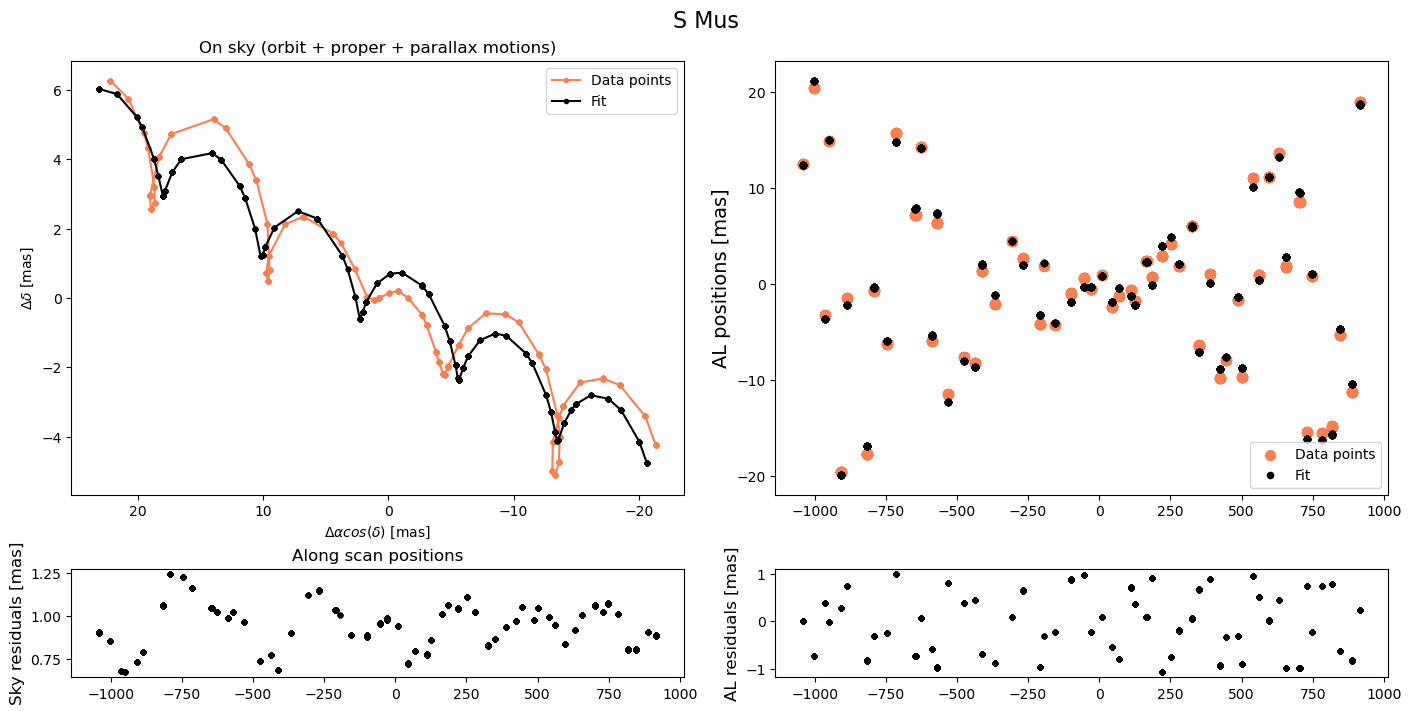

In [56]:
sb_SMus.PlotSSfit() # Plot single-star fit to simulated data
# If you want to get fitted parameters and along-scan positions
# p_fit, w_fit = sb.fitSS(sb.w_bs)

This package contains a short-cut to fit epoch astrometry with kepmodel (https://gitlab.unige.ch/delisle/kepmodel/-/tree/main?ref_type=heads) package.

In [57]:
fG = fitGaia(params_SMus['Object'], DataRelease=4) # initialize fitting
fG.load_dataframe(sim_astrometry) # give data to fit, can be a dataframe from simulations or a file
# fG.load_file('your/folder/filename_to_use') if needed from a file
fit_parameters = fG.fit_kepmodel() # fit using kepmodel. fit_dir='your/folder' to save resulting parameters

Parameter                        Value     Error       
lin.ra                        -0.17262  ±  0.00798     
lin.dec                       -0.05501  ±  0.00814     
lin.parallax                   1.13983  ±  0.00954     
lin.mura                      -7.86740  ±  0.00509     
lin.mudec                     -1.76378  ±  0.00502     
chi2r ss 3.7396742256573727
chi2r bs 0.019616604403128946
Parameter                        Value     Error       
lin.ra                         -0.0259  ±  0.0290      
lin.dec                         0.0148  ±  0.0228      
lin.parallax                    1.1610  ±  0.0100      
lin.mura                      -7.89882  ±  0.00522     
lin.mudec                     -1.80797  ±  0.00519     
kep.0.P                        505.999  ±  0.578       
kep.0.Tp                        -247.6  ±  15.9        
kep.0.as                        1.0367  ±  0.0115      
kep.0.e                         0.0806  ±  0.0178      
kep.0.w [deg]                     28.3  ±  11.

Text(0, 0.5, 'Along scan, [mas]')

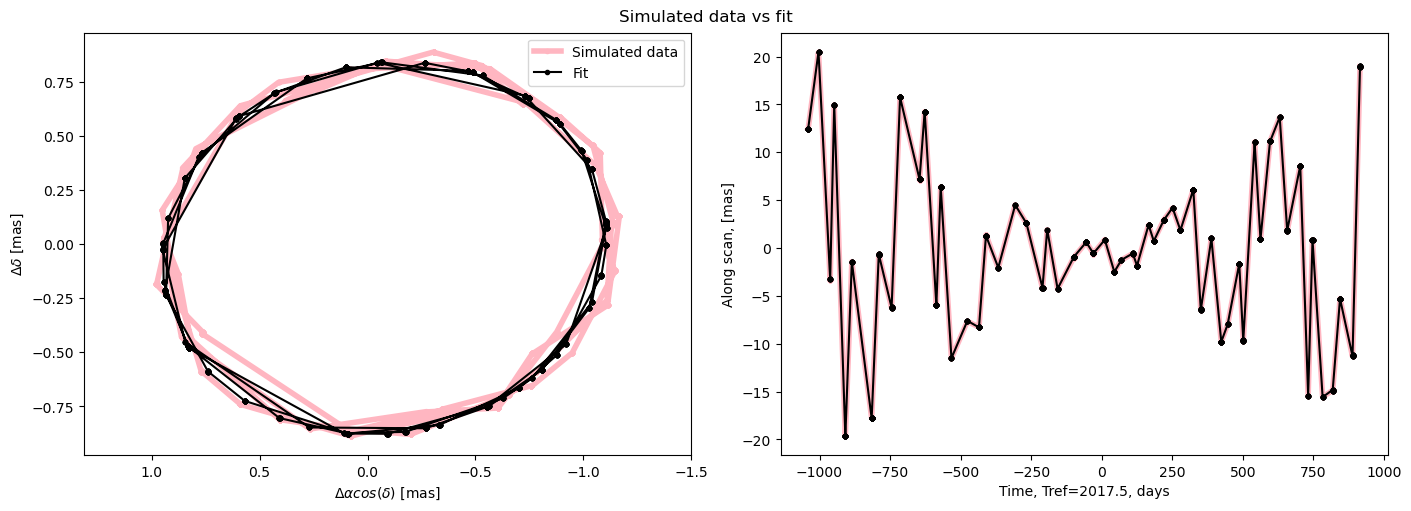

In [58]:
w_fit = fG.keplerian_model.model() # fitted along scan
ra_fit, dec_fit = sb_SMus.orbit(fit_parameters, sb_SMus.reltimes) # fitted
ra_ph, dec_ph = sb_SMus.Data['ra_ph'], sb_SMus.Data['dec_ph'] # photocentric orbit

fig, axs = plt.subplots(1,2, figsize=(14, 5), constrained_layout=True)
ax1, ax2 = axs
fig.suptitle('Simulated data vs fit')
ax1.plot(ra_ph, dec_ph, label = 'Simulated data', marker='.', lw = 4, color='lightpink')
ax1.plot(ra_fit, dec_fit, label = 'Fit', marker='.', color = 'black')
ax1.set_aspect('equal', adjustable='datalim')
ax1.xaxis.set_inverted(True)
ax1.set_xlabel(r'$\Delta \alpha cos(\delta)$ [mas]')
ax1.set_ylabel(r'$\Delta \delta$ [mas]')
ax1.legend()

ax2.plot(sb_SMus.reltimes, sb_SMus.w_bs, marker='.', lw = 4, color='lightpink') #sb.timesjd to have time in JD
ax2.plot(sb_SMus.reltimes, w_fit, marker='.', color = 'black')
ax2.set_xlabel(f'Time, Tref={sb_SMus.Tref}, days')
ax2.set_ylabel('Along scan, [mas]')

### Gaia BH3

Now let’s consider the Gaia BH3 case presented in Gaia Collaboration 2024 (A&A, 686, L2 (2024), https://doi.org/10.1051/0004-6361/202449763
).

As this system was treated with a binary model, there is no need to apply a proper motion correction. For this, we provide the 'pmra' and 'pmdec' parameters from the cited paper.

In [59]:
params_BH3 = {'Object': 'BH3', #simbad resolved name
 'id3': str(4318465066420528000), #if no gaia resolved name, write gaia dr3 id here
 'type': 'BH', # can be 'binary' or 'BH'
 'P': 4253.1,
 'a': 27.39,
 'e': 0.7291,
 'i': 110.580,
 'Omega': 136.236,
 'w': 77.34,
 'T0': 2458177.39,
 'q': 43.0263,
 'plx': 1.6933,
 'pmra': -28.317,
 'pmdec': -155.221,
 'Vtot': 11.231088,
 'ra': 294.8278502411,
 'dec': 14.930919072,
 'ra0': 4.2798,
 'dec0': 2.4015,
}

sb_BH3 = SimBinary(params_BH3, DataRelease = 4) # DataRelease from 1 to 5

You may notice that the cell runs quickly and without output. Since all parameters were provided, no queries were required.

None None False


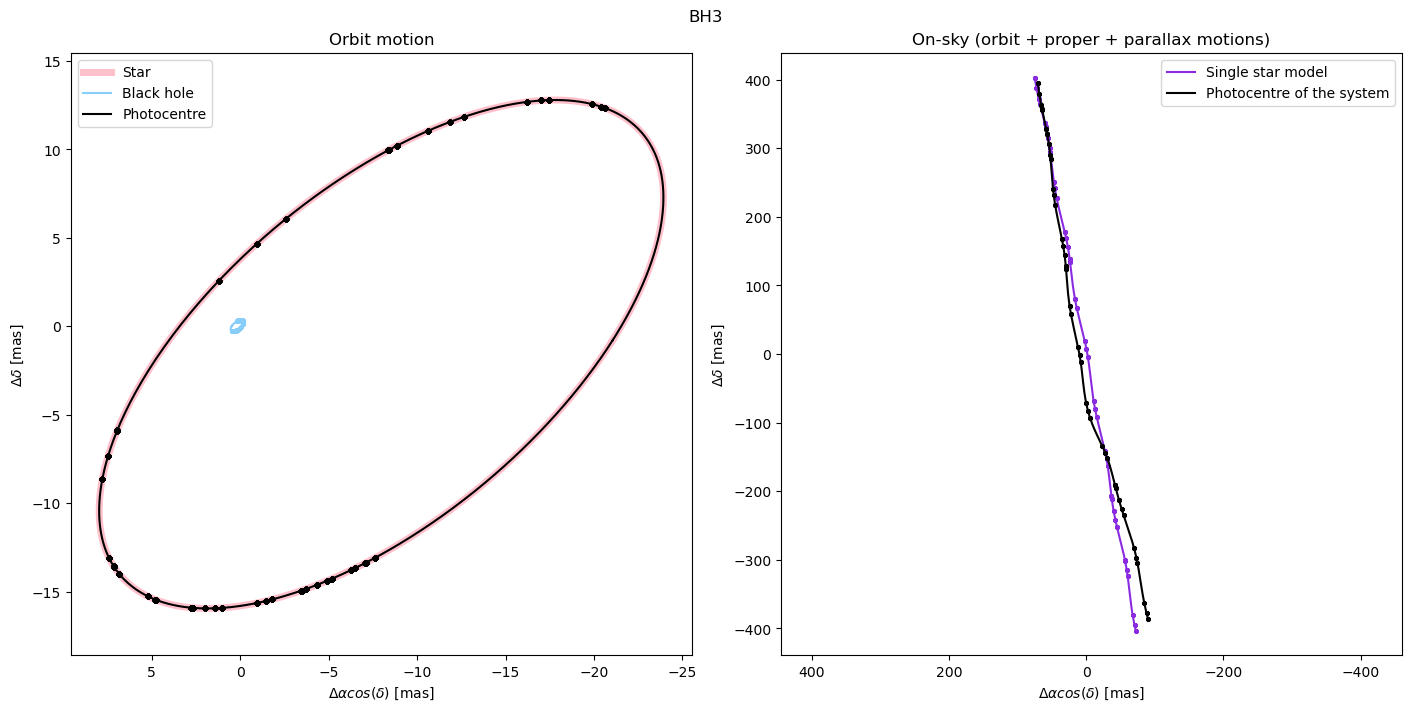

In [60]:
axs = sb_BH3.Plot(Npoints=500)

## Adding noise

Previously we simulated noise-less data. It is possible to add noise by indicating errCCD = True.

Text(0, 0.5, 'Residuals, [mas]')

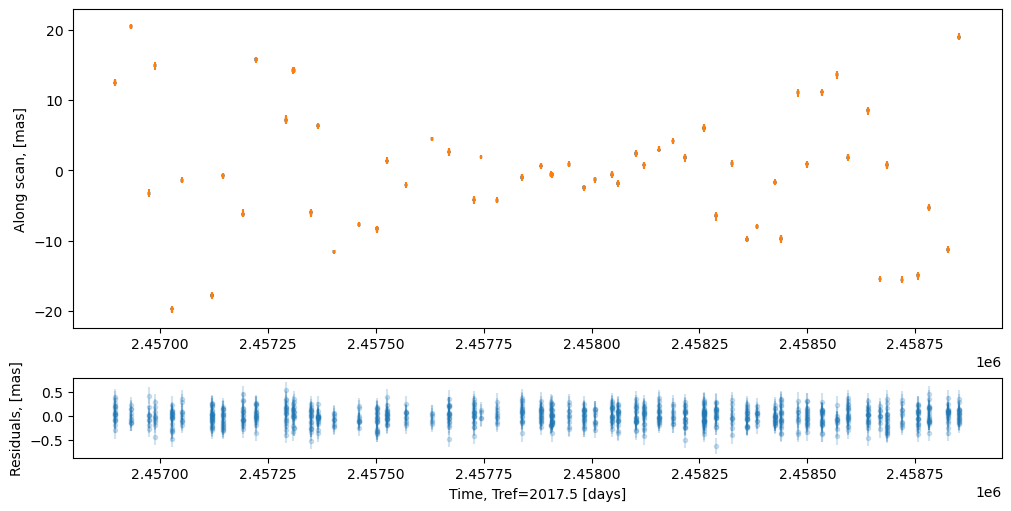

In [61]:
# why query again if we already have everything...
additional_params = {
    'pmra': sb_SMus.ObjectPMRA,
    'pmdec': sb_SMus.ObjectPMDEC,
    'ra': sb_SMus.ObjectRA,
    'dec': sb_SMus.ObjectDEC,
    'id3': sb_SMus.id3,
    'Vtot': sb_SMus.ObjectGmag
}

updated_params = params_SMus | additional_params


sb_noise = SimBinary(updated_params, DataRelease = 4, errCCD=True) # DataRelease from 1 to 5
sim_astrometry_noise = sb_noise.get_dataframe()

fig, axs = plt.subplots(2,1, figsize=(10, 5), constrained_layout=True, height_ratios=[4, 1])
ax1, ax2 = axs

ax1.errorbar(sim_astrometry['obs_time_tcb'], sim_astrometry['centroid_pos_al'], yerr = sim_astrometry['centroid_pos_error_al'], ls='')
ax1.set_ylabel('Along scan, [mas]')

ax1.errorbar(sim_astrometry_noise['obs_time_tcb'], sim_astrometry_noise['centroid_pos_al'], yerr = sim_astrometry_noise['centroid_pos_error_al'], ls='')
ax1.set_ylabel('Along scan, [mas]')

ax2.errorbar(sim_astrometry['obs_time_tcb'], sim_astrometry_noise['centroid_pos_al']-sim_astrometry['centroid_pos_al'], yerr = sim_astrometry['centroid_pos_error_al'], ls='', alpha=0.2, marker='.')

ax2.set_xlabel(f'Time, Tref={sb.Tref} [days]')
ax2.set_ylabel('Residuals, [mas]')